# Variational Quantum Classifier


In this notebook, we are going to train Qiskit Machine Learning's Variational Quantum Classifier to classify instances of a dataset.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit.circuit.library import n_local, zz_feature_map
from qiskit_machine_learning.algorithms import VQC
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_machine_learning.primitives import QMLSampler
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

We choose the feature map and the variational form

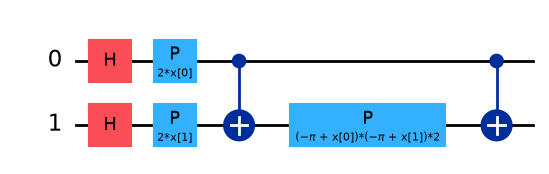

In [2]:
feature_map = zz_feature_map(feature_dimension=2, reps=1, entanglement='linear')
feature_map.draw(output="mpl")

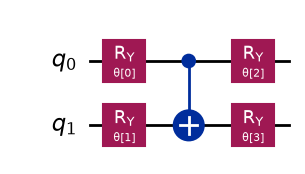

In [3]:
var_form = n_local(num_qubits=2, rotation_blocks='ry', entanglement_blocks='cx', entanglement='linear', reps=1)
var_form.draw(output="mpl")

We create the training dataset

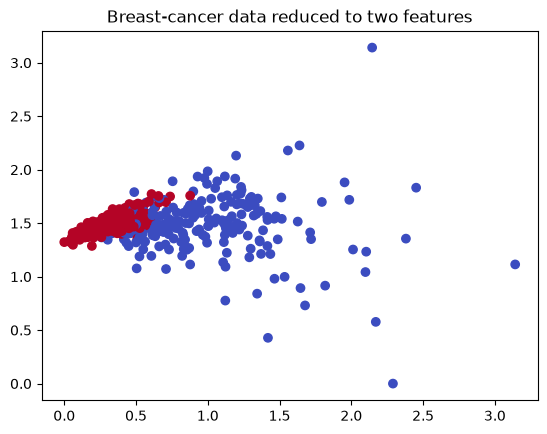

In [4]:
dataset = load_breast_cancer()
features = PCA(n_components=2).fit_transform(dataset.data)
features = MinMaxScaler(feature_range=(0, np.pi)).fit_transform(features)

training_input, test_input, training_labels, test_labels = train_test_split(
    features,
    dataset.target,
    train_size=200,
    test_size=20,
    stratify=dataset.target,
    random_state=2020,
)

plt.scatter(features[:, 0], features[:, 1], c=dataset.target, cmap="coolwarm")
plt.title("Breast-cancer data reduced to two features");

After we have generated the training data and defined the feature map and variational form, we can now train the VQC. 

In [5]:
sampler = QMLSampler(shots=None)
optimizer = COBYLA()
vqc = VQC(optimizer=optimizer, feature_map=feature_map, ansatz=var_form, sampler=sampler)
vqc.fit(training_input, training_labels)
print("Accuracy: ", vqc.score(test_input, test_labels))

Accuracy:  1.0


We now select more complicated feature maps and variational forms

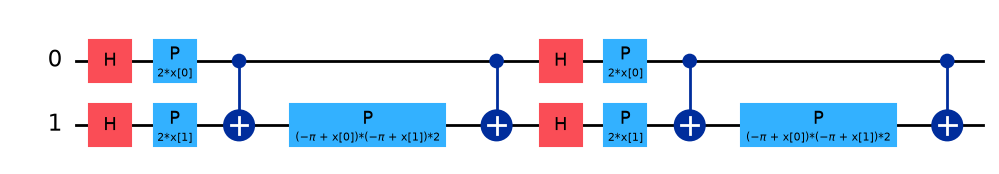

In [6]:
feature_map = zz_feature_map(feature_dimension=2, reps=2, entanglement='linear')
feature_map.draw(output="mpl")

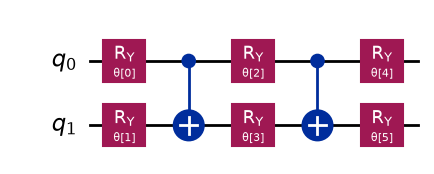

In [7]:
var_form = n_local(num_qubits=2, rotation_blocks='ry', entanglement_blocks='cx', entanglement='linear', reps=2)
var_form.draw(output="mpl")

And we train again the VQC

In [8]:
vqc = VQC(optimizer=optimizer, feature_map=feature_map, ansatz=var_form, sampler=sampler)
vqc.fit(training_input, training_labels)
print("Accuracy: ", vqc.score(test_input, test_labels))

Accuracy:  1.0
